# Stage 05 — Primary Treatment-Effect Analysis

Stage 04 found no evidence of sample ratio mismatch under the assumed equal allocation and closely balanced observable baseline characteristics. Its statistical plan was specified before formal outcome testing. Stage 05 now estimates treatment effects and uncertainty. Effect estimation quantifies an estimated difference and interval; hypothesis testing evaluates compatibility with a no-effect null. The objective is not merely to find small p-values.

## 1. Pre-specified analysis framework

Control: No E-Mail. Treatments: Mens E-Mail and Womens E-Mail. Primary metric: mean spend per assigned experimental unit. Secondary metrics: conversion rate and visit rate. Primary comparisons: each email treatment versus No E-Mail. Alpha is 0.05 with 95% confidence intervals. Holm correction is applied to the two spend comparisons, separately to the two conversion comparisons, and separately to the two visit comparisons.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from src.statistical_tests import (
    bootstrap_mean_difference,
    holm_adjusted_p_values,
    proportion_treatment_effect,
    welch_mean_comparison,
)

project_root = Path('.')
if not (project_root / 'data/processed/Hillstrom_clean.csv').exists():
    project_root = Path('..')
raw_path = project_root / 'data/raw/Hillstrom.csv'
processed_path = project_root / 'data/processed/Hillstrom_clean.csv'
figure_dir = project_root / 'outputs/figures'
table_dir = project_root / 'outputs/tables'
control_group = 'No E-Mail'
treatment_groups = ['Mens E-Mail', 'Womens E-Mail']
group_order = [control_group, *treatment_groups]
alpha = 0.05
bootstrap_seed = 20260918
bootstrap_resamples = 10000

def file_sha256(path):
    return sha256(path.read_bytes()).hexdigest()

raw_hash_before = file_sha256(raw_path)
processed_hash_before = file_sha256(processed_path)
data = pd.read_csv(processed_path)
print('Loaded {:,} observations from {}'.format(len(data), processed_path))
print('Bootstrap resamples: {:,}; seed: {}'.format(bootstrap_resamples, bootstrap_seed))

Loaded 64,000 observations from data/processed/Hillstrom_clean.csv
Bootstrap resamples: 10,000; seed: 20260918


## 2. Descriptive analysis table

This table describes observed group outcomes. It is not a substitute for effect estimation or hypothesis testing.

In [2]:
descriptive_table = data.groupby('segment', observed=True).agg(
    **{'Sample Size': ('segment', 'size'), 'Total Spend': ('spend', 'sum'), 'Mean Spend': ('spend', 'mean'), 'Median Spend': ('spend', 'median'), 'Positive-Spend Rate': ('spend', lambda x: (x > 0).mean()), 'Conversion Count': ('conversion', 'sum'), 'Conversion Rate': ('conversion', 'mean'), 'Visit Count': ('visit', 'sum'), 'Visit Rate': ('visit', 'mean')}
).reindex(group_order)
for column in ['Positive-Spend Rate', 'Conversion Rate', 'Visit Rate']:
    descriptive_table[column] = (descriptive_table[column] * 100).round(2)
display(descriptive_table.round(2))

,Sample Size,Total Spend,Mean Spend,Median Spend,Positive-Spend Rate,Conversion Count,Conversion Rate,Visit Count,Visit Rate
segment,,,,,,,,,
No E-Mail,21306,13908.33,0.65,0.0,0.57,122,0.57,2262,10.62
Mens E-Mail,21307,30311.69,1.42,0.0,1.25,267,1.25,3894,18.28
Womens E-Mail,21387,23038.11,1.08,0.0,0.88,189,0.88,3238,15.14


## 3. Effect measures

The primary spend effect is treatment mean spend minus control mean spend, in dollars per assigned experimental unit. Relative lift is supplementary because a small control mean can make it appear large. For conversion and visit, effects are absolute risk differences in percentage points, relative lift, and 95% confidence intervals for the absolute difference.

## 4. Primary spend analysis: percentile bootstrap confidence intervals

Spend is extremely zero-inflated and right-skewed. The primary uncertainty estimate is a nonparametric percentile bootstrap for the difference in mean spend per assigned unit. Each comparison uses 10,000 resamples with a fixed seed. A percentile interval is straightforward and consistently applied, but like any bootstrap interval may have limitations in highly skewed distributions. The bootstrap is not used to manufacture p-values.

In [3]:
control_spend = data.loc[data['segment'] == control_group, 'spend'].to_numpy()
bootstrap_rng = np.random.default_rng(bootstrap_seed)
spend_results = []
for treatment_group in treatment_groups:
    treatment_spend = data.loc[data['segment'] == treatment_group, 'spend'].to_numpy()
    bootstrap_result = bootstrap_mean_difference(
        treatment_spend, control_spend, bootstrap_rng, bootstrap_resamples
    )
    welch_result = welch_mean_comparison(treatment_spend, control_spend)
    effect = welch_result['effect']
    spend_results.append({'Outcome': 'Spend', 'Treatment': treatment_group, 'Control': control_group, 'Treatment Metric': treatment_spend.mean(), 'Control Metric': control_spend.mean(), 'Absolute Effect': effect, 'Relative Lift': effect / control_spend.mean(), 'CI Lower': bootstrap_result['ci_lower'], 'CI Upper': bootstrap_result['ci_upper'], 'Bootstrap SE': bootstrap_result['standard_error'], 'Raw P-Value': welch_result['p_value'], 'Inference Method': 'Percentile bootstrap CI; Welch t-test reference p-value'})

spend_results = pd.DataFrame(spend_results)
spend_results['Holm Adjusted P-Value'] = holm_adjusted_p_values(spend_results['Raw P-Value'], alpha)
spend_results['Adjusted Significant'] = spend_results['Holm Adjusted P-Value'] < alpha
display(spend_results.round(6))


,Outcome,Treatment,Control,Treatment Metric,Control Metric,Absolute Effect,Relative Lift,CI Lower,CI Upper,Bootstrap SE,Raw P-Value,Inference Method,Holm Adjusted P-Value,Adjusted Significant
0,Spend,Mens E-Mail,No E-Mail,1.422617,0.652789,0.769827,1.179289,0.491570,1.058785,0.14501,0.000000,Percentile bootstrap CI; Welch t-test referenc...,0.000000,True
1,Spend,Womens E-Mail,No E-Mail,1.077202,0.652789,0.424412,0.650152,0.170684,0.685662,0.12990,0.001129,Percentile bootstrap CI; Welch t-test referenc...,0.001129,True


## 5. Spend hypothesis testing and multiplicity

The reference hypothesis for each comparison is H0: mean spend is equal between treatment and control; H1: mean spend differs. Welch two-sample tests provide the raw reference p-values because they allow unequal variances and sample sizes are large. They do not make spend normally distributed. Bootstrap intervals remain the primary uncertainty estimate. Holm adjustment is relevant because both primary spend hypotheses are interpreted as one family.

## 6. Spend treatment-effect visualization

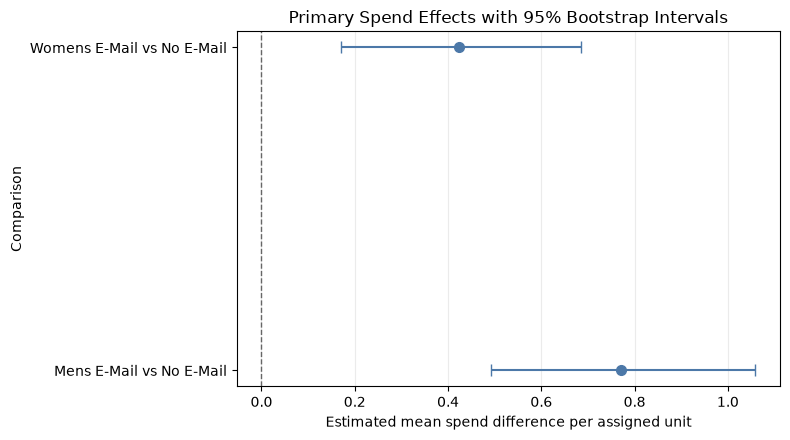

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y_positions = np.arange(len(spend_results))
effects = spend_results['Absolute Effect'].to_numpy()
lower_errors = effects - spend_results['CI Lower'].to_numpy()
upper_errors = spend_results['CI Upper'].to_numpy() - effects
ax.errorbar(effects, y_positions, xerr=np.vstack([lower_errors, upper_errors]), fmt='o', color='#4C78A8', capsize=4, markersize=7)
ax.axvline(0, color='#666666', linestyle='--', linewidth=1)
ax.set_yticks(y_positions, spend_results['Treatment'] + ' vs ' + control_group)
ax.set_xlabel('Estimated mean spend difference per assigned unit')
ax.set_ylabel('Comparison')
ax.set_title('Primary Spend Effects with 95% Bootstrap Intervals')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
fig.savefig(figure_dir / 'spend_treatment_effects.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Secondary binary-outcome analyses

For each outcome and treatment-control comparison, H0 states equal outcome probabilities and H1 states different probabilities. Two-sided two-sample proportion tests provide raw p-values. Wald 95% confidence intervals are reported for the absolute risk difference; large group sizes make this normal-approximation interval appropriate here. Holm correction is applied separately within conversion and visit families.

In [5]:
def binary_effect_results(outcome):
    '''Create the validated outcome table using shared binary-inference utilities.'''
    control_values = data.loc[data['segment'] == control_group, outcome]
    rows = []
    for treatment_group in treatment_groups:
        treatment_values = data.loc[data['segment'] == treatment_group, outcome]
        effect_result = proportion_treatment_effect(
            int(treatment_values.sum()), len(treatment_values), int(control_values.sum()), len(control_values)
        )
        rows.append({'Outcome': outcome.title(), 'Treatment': treatment_group, 'Control': control_group, 'Treatment Metric': effect_result['treatment_rate'], 'Control Metric': effect_result['control_rate'], 'Absolute Effect': effect_result['effect'], 'Relative Lift': effect_result['relative_lift'], 'CI Lower': effect_result['ci_lower'], 'CI Upper': effect_result['ci_upper'], 'Raw P-Value': effect_result['p_value'], 'Inference Method': 'Two-sample proportion z-test; Wald CI'})
    result = pd.DataFrame(rows)
    result['Holm Adjusted P-Value'] = holm_adjusted_p_values(result['Raw P-Value'], alpha)
    result['Adjusted Significant'] = result['Holm Adjusted P-Value'] < alpha
    return result

conversion_results = binary_effect_results('conversion')
visit_results = binary_effect_results('visit')
display(conversion_results.round(6))
display(visit_results.round(6))


,Outcome,Treatment,Control,Treatment Metric,Control Metric,Absolute Effect,Relative Lift,CI Lower,CI Upper,Raw P-Value,Inference Method,Holm Adjusted P-Value,Adjusted Significant
0,Conversion,Mens E-Mail,No E-Mail,0.012531,0.005726,0.006805,1.188422,0.005000,0.008610,0.000000,Two-sample proportion z-test; Wald CI,0.000000,True
1,Conversion,Womens E-Mail,No E-Mail,0.008837,0.005726,0.003111,0.543313,0.001499,0.004723,0.000157,Two-sample proportion z-test; Wald CI,0.000157,True


,Outcome,Treatment,Control,Treatment Metric,Control Metric,Absolute Effect,Relative Lift,CI Lower,CI Upper,Raw P-Value,Inference Method,Holm Adjusted P-Value,Adjusted Significant
0,Visit,Mens E-Mail,No E-Mail,0.182757,0.106167,0.076590,0.721405,0.069954,0.083226,0.0,Two-sample proportion z-test; Wald CI,0.0,True
1,Visit,Womens E-Mail,No E-Mail,0.151400,0.106167,0.045233,0.426055,0.038894,0.051572,0.0,Two-sample proportion z-test; Wald CI,0.0,True


## 8. Binary-outcome effect visualization

Effects are shown in percentage points against a zero-effect reference. The panels use untruncated, clearly labelled axes within each outcome.

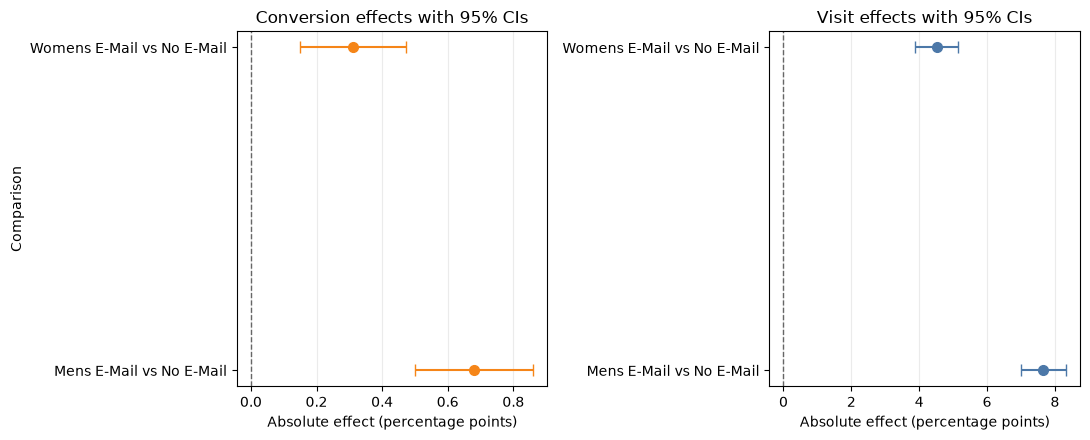

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, result, color in zip(axes, [conversion_results, visit_results], ['#F58518', '#4C78A8']):
    effects_pp = result['Absolute Effect'].to_numpy() * 100
    lower_errors = effects_pp - result['CI Lower'].to_numpy() * 100
    upper_errors = result['CI Upper'].to_numpy() * 100 - effects_pp
    y_positions = np.arange(len(result))
    ax.errorbar(effects_pp, y_positions, xerr=np.vstack([lower_errors, upper_errors]), fmt='o', color=color, capsize=4, markersize=7)
    ax.axvline(0, color='#666666', linestyle='--', linewidth=1)
    ax.set_yticks(y_positions, result['Treatment'] + ' vs ' + control_group)
    ax.set_xlabel('Absolute effect (percentage points)')
    ax.set_title('{} effects with 95% CIs'.format(result['Outcome'].iloc[0]))
    ax.grid(axis='x', alpha=0.25)
axes[0].set_ylabel('Comparison')
plt.tight_layout()
fig.savefig(figure_dir / 'binary_treatment_effects.png', dpi=160, bbox_inches='tight')
plt.show()

## Statistical vs Practical Significance

Statistical evidence is assessed with confidence intervals and Holm-adjusted p-values. Practical magnitude is assessed with absolute effect and relative lift, including the increase per assigned customer. A statistically precise estimate can still be small in business terms, and a large-looking relative lift can correspond to a small absolute effect when the control rate is low. No business recommendation is made in this notebook.

## 9. Business-scale interpretation

The following translates observed estimated effects to a common scale of 1,000 assigned customers. These are effect-scaled interpretations of this experiment, not forecasts: no future population, margin, campaign cost, or customer lifetime value is assumed.

In [7]:
business_scale = pd.concat([spend_results, conversion_results, visit_results], ignore_index=True)
business_scale['Effect per 1,000 Assigned'] = business_scale['Absolute Effect'] * 1000
business_scale['Effect Unit'] = np.where(business_scale['Outcome'] == 'Spend', 'additional spend per 1,000 assigned', 'additional outcome events per 1,000 assigned')
display(business_scale[['Outcome', 'Treatment', 'Absolute Effect', 'Effect per 1,000 Assigned', 'Effect Unit']].round(3))

,Outcome,Treatment,Absolute Effect,"Effect per 1,000 Assigned",Effect Unit
0,Spend,Mens E-Mail,0.770,769.827,"additional spend per 1,000 assigned"
1,Spend,Womens E-Mail,0.424,424.412,"additional spend per 1,000 assigned"
2,Conversion,Mens E-Mail,0.007,6.805,"additional outcome events per 1,000 assigned"
3,Conversion,Womens E-Mail,0.003,3.111,"additional outcome events per 1,000 assigned"
4,Visit,Mens E-Mail,0.077,76.590,"additional outcome events per 1,000 assigned"
5,Visit,Womens E-Mail,0.045,45.233,"additional outcome events per 1,000 assigned"


## 10. Supporting spend decomposition

Expected spend can be described as positive-spend probability multiplied by mean spend conditional on positive spend. This is supporting descriptive context only. Conditional spend among purchasers is not a clean causal effect because conditioning on a post-treatment variable can introduce selection bias.

In [8]:
spend_decomposition = data.groupby('segment', observed=True).agg(
    **{'Positive-Spend Probability': ('spend', lambda x: (x > 0).mean()), 'Mean Spend Among Positive Spenders': ('spend', lambda x: x[x > 0].mean()), 'Median Spend Among Positive Spenders': ('spend', lambda x: x[x > 0].median())}
).reindex(group_order)
spend_decomposition['Positive-Spend Probability'] = (spend_decomposition['Positive-Spend Probability'] * 100).round(2)
display(spend_decomposition.round(2))

,Positive-Spend Probability,Mean Spend Among Positive Spenders,Median Spend Among Positive Spenders
segment,,,
No E-Mail,0.57,114.00,88.36
Mens E-Mail,1.25,113.53,66.98
Womens E-Mail,0.88,121.89,94.71


## 11. Sensitivity and reference analysis

The primary spend uncertainty analysis is the bootstrap percentile interval. The Welch result is a conventional mean-comparison reference analysis. Their qualitative agreement is evaluated by whether the bootstrap interval excludes zero and the Holm-adjusted Welch result is below alpha; no unnecessary alternative tests are added.

In [9]:
spend_results['Bootstrap CI Excludes Zero'] = (spend_results['CI Lower'] > 0) | (spend_results['CI Upper'] < 0)
spend_results['Bootstrap and Welch Agree'] = spend_results['Bootstrap CI Excludes Zero'] == spend_results['Adjusted Significant']
display(spend_results[['Treatment', 'Bootstrap CI Excludes Zero', 'Adjusted Significant', 'Bootstrap and Welch Agree']])

,Treatment,Bootstrap CI Excludes Zero,Adjusted Significant,Bootstrap and Welch Agree
0,Mens E-Mail,True,True,True
1,Womens E-Mail,True,True,True


## 12. Master results table

All effects compare the listed treatment with No E-Mail. Spend effects and intervals are in dollars per assigned unit; conversion and visit effects and intervals are proportions in the saved table.

In [10]:
primary_results = pd.concat([spend_results, conversion_results, visit_results], ignore_index=True)
primary_results = primary_results[['Outcome', 'Treatment', 'Control', 'Treatment Metric', 'Control Metric', 'Absolute Effect', 'Relative Lift', 'CI Lower', 'CI Upper', 'Raw P-Value', 'Holm Adjusted P-Value', 'Adjusted Significant', 'Inference Method']]
display(primary_results.round(6))
primary_results.to_csv(table_dir / 'primary_treatment_effects.csv', index=False)
print('Saved outputs/tables/primary_treatment_effects.csv')

,Outcome,Treatment,Control,Treatment Metric,Control Metric,Absolute Effect,Relative Lift,CI Lower,CI Upper,Raw P-Value,Holm Adjusted P-Value,Adjusted Significant,Inference Method
0,Spend,Mens E-Mail,No E-Mail,1.422617,0.652789,0.769827,1.179289,0.491570,1.058785,0.000000,0.000000,True,Percentile bootstrap CI; Welch t-test referenc...
1,Spend,Womens E-Mail,No E-Mail,1.077202,0.652789,0.424412,0.650152,0.170684,0.685662,0.001129,0.001129,True,Percentile bootstrap CI; Welch t-test referenc...
2,Conversion,Mens E-Mail,No E-Mail,0.012531,0.005726,0.006805,1.188422,0.005000,0.008610,0.000000,0.000000,True,Two-sample proportion z-test; Wald CI
3,Conversion,Womens E-Mail,No E-Mail,0.008837,0.005726,0.003111,0.543313,0.001499,0.004723,0.000157,0.000157,True,Two-sample proportion z-test; Wald CI
4,Visit,Mens E-Mail,No E-Mail,0.182757,0.106167,0.076590,0.721405,0.069954,0.083226,0.000000,0.000000,True,Two-sample proportion z-test; Wald CI
5,Visit,Womens E-Mail,No E-Mail,0.151400,0.106167,0.045233,0.426055,0.038894,0.051572,0.000000,0.000000,True,Two-sample proportion z-test; Wald CI


Saved outputs/tables/primary_treatment_effects.csv


## 13. Limitations

Interpretation is limited by the lack of a customer identifier, experiment timestamp, documented allocation ratio, known outcome window, original pre-registered primary metric, and original experiment hypotheses. The project-selected primary metric is spend; spend is extremely zero-inflated and skewed; and duplicate experimental units cannot be independently verified. These constraints limit what can be inferred beyond the observed experiment data.

# Stage 05 Findings

**Primary outcome — spend.** The table above reports treatment and control means, estimated mean differences, relative lifts, percentile-bootstrap 95% intervals, Welch raw p-values, and Holm-adjusted p-values for the two pre-specified comparisons.

**Secondary outcomes — conversion and visit.** The master table reports absolute risk differences, 95% intervals, and separately Holm-adjusted inference for each secondary outcome family.

Statistical evidence is interpreted with adjusted p-values and intervals; practical magnitude is interpreted with absolute effects per assigned customer and per 1,000 assigned customers. The bootstrap and Welch reference analyses are compared explicitly. Remaining uncertainty includes skewed spend, unknown outcome timing, and incomplete experiment documentation. No subgroup treatment-effect analysis, power analysis, final business recommendation, or claim of a treatment winner is made here.

## 14. File-integrity and framework confirmation

In [11]:
raw_hash_after = file_sha256(raw_path)
processed_hash_after = file_sha256(processed_path)
print('Raw dataset unchanged during notebook execution:', raw_hash_before == raw_hash_after)
print('Processed dataset unchanged during notebook execution:', processed_hash_before == processed_hash_after)
print('Stage 04 framework followed: fixed primary metric, comparisons, alpha, and separate Holm families.')

Raw dataset unchanged during notebook execution: True
Processed dataset unchanged during notebook execution: True
Stage 04 framework followed: fixed primary metric, comparisons, alpha, and separate Holm families.
